# RSI Portfolio Trader (Equal-Weight Rebalancing)

This notebook applies the RSI+MA buy/sell logic to a portfolio of stocks loaded from a Python object (dictionary of CSV files).

- Buy/sell signals are generated per stock
- Portfolio holds only stocks with active long positions
- Capital is equally weighted across currently active stocks
- Reweighting happens automatically whenever signals change
- Strategy is compared against an equal-weight buy-and-hold benchmark
- Transaction cost is included: `tc = 0.15%` per one-way portfolio turnover

In [1]:
# Imports and setup
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is on sys.path so we can import src.test_strategy
proj_root = Path('..').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from src.test_strategy import test_strategy

plt.rcParams['figure.figsize'] = (12, 6)

# Object of input CSV files (portfolio universe)
portfolio_files = {
    'DnB': '../tests/DnB Stock Price History.csv',
    'Nordea': '../tests/Nordea Bank Stock Price History.csv',
    'Storebrand': '../tests/Storebrand Stock Price History.csv',
    'Sparebank 1 SR Bank ASA': '../tests/Sparebank 1 SR Bank ASA Stock Price History.csv',
}

# Risk-free source (same as existing project logic)
rf_path = '../data/processed/10-Year-Government-Bond-Yield-Norway.csv'

In [2]:
def load_and_merge_prices(file_map: dict[str, str]) -> pd.DataFrame:
    """Load each stock CSV and merge into one Date-indexed price DataFrame."""
    price_series = []

    for name, path in file_map.items():
        s = (
            pd.read_csv(path, parse_dates=['Date'], index_col='Date')[::-1]['Price']
            .astype(float)
            .rename(name)
        )
        price_series.append(s)

    prices = pd.concat(price_series, axis=1).sort_index()

    # Keep common dates across all stocks to maintain true equal-weight comparability
    prices = prices.dropna(how='any')
    return prices


prices = load_and_merge_prices(portfolio_files)
prices.head()

,DnB,Nordea,Storebrand,Sparebank 1 SR Bank ASA
Date,,,,
2015-01-05,106.8,9.395,29.03,51.75
2015-01-07,104.6,9.260,28.17,51.25
2015-01-08,107.0,9.370,28.60,51.25
2015-01-09,105.3,9.200,27.82,51.25
2015-01-12,103.0,9.225,27.69,50.50


In [3]:
def RSI_scorer(df: pd.DataFrame, period: int = 14, ma_short: int = 100, ma_long: int = 200) -> pd.DataFrame:
    """
    Portfolio-safe RSI + moving-average signal logic (same logic as RSI_trader):

    Buy:  (RSI < 30 AND MA_short > MA_long) OR (MA50 > MA_short)
    Sell: (RSI > 70 AND Price < MA_long) OR (MA_short < MA_long)
    """
    out = df.copy()

    delta = out['Price'].diff()
    gain = delta.clip(lower=0).rolling(window=period).mean()
    loss = (-delta.clip(upper=0)).rolling(window=period).mean()

    rs = gain / loss.replace(0, np.nan)
    out['RSI'] = 100 - (100 / (1 + rs))

    out['MA50'] = out['Price'].rolling(window=50).mean()
    out['MA100'] = out['Price'].rolling(window=ma_short).mean()
    out['MA200'] = out['Price'].rolling(window=ma_long).mean()

    out['Signal'] = 0

    buy_cond = ((out['RSI'] < 30) & (out['MA100'] > out['MA200']))
    sell_cond = ((out['RSI'] > 70) & (out['Price'] < out['MA200'])) | (out['MA100'] < out['MA200'])

    start = max(ma_long, period)
    if len(out) > start:
        valid = pd.Series(False, index=out.index)
        valid.iloc[start:] = True

        out.loc[valid & buy_cond, 'Signal'] = 1
        out.loc[valid & sell_cond, 'Signal'] = -1  # sell overrides buy if both are true

    return out

In [4]:
# Build per-stock signals
signal_df = pd.DataFrame(index=prices.index, columns=prices.columns, data=0, dtype=int)

for stock in prices.columns:
    stock_scored = RSI_scorer(pd.DataFrame({'Price': prices[stock]}), period=14, ma_short=100, ma_long=200)
    signal_df[stock] = stock_scored['Signal'].reindex(prices.index).fillna(0).astype(int)

signal_df.tail()

,DnB,Nordea,Storebrand,Sparebank 1 SR Bank ASA
Date,,,,
2019-11-22,-1,-1,-1,-1
2019-11-25,-1,-1,-1,-1
2019-11-26,-1,-1,-1,-1
2019-11-27,-1,-1,-1,-1
2019-11-28,-1,-1,-1,-1


In [5]:
# Convert signals -> positions (hold until explicit sell)
positions = pd.DataFrame(index=prices.index, columns=prices.columns, data=0, dtype=float)
current_pos = {stock: 0 for stock in prices.columns}

for i in range(1, len(prices)):
    prev_signals = signal_df.iloc[i - 1]

    for stock in prices.columns:
        s = prev_signals[stock]
        if s == 1:
            current_pos[stock] = 1
        elif s == -1:
            current_pos[stock] = 0

        positions.loc[prices.index[i], stock] = current_pos[stock]

# Equal weight across active holdings; if no active holding, go to cash (risk-free)
active_count = positions.sum(axis=1)
weights = positions.div(active_count.replace(0, np.nan), axis=0).fillna(0.0)
cash_weight = (active_count == 0).astype(float)

weights.head()

,DnB,Nordea,Storebrand,Sparebank 1 SR Bank ASA
Date,,,,
2015-01-05,0.0,0.0,0.0,0.0
2015-01-07,0.0,0.0,0.0,0.0
2015-01-08,0.0,0.0,0.0,0.0
2015-01-09,0.0,0.0,0.0,0.0
2015-01-12,0.0,0.0,0.0,0.0


Strategy total return (net of TC): 126.85%
Buy&Hold equal-weight total return: 60.08%
Evaluation starts after warmup days: 200
Days with at least one active position (eval window): 85.71%
Average one-way daily turnover: 1.2883%
Average daily TC drag: 0.0019%


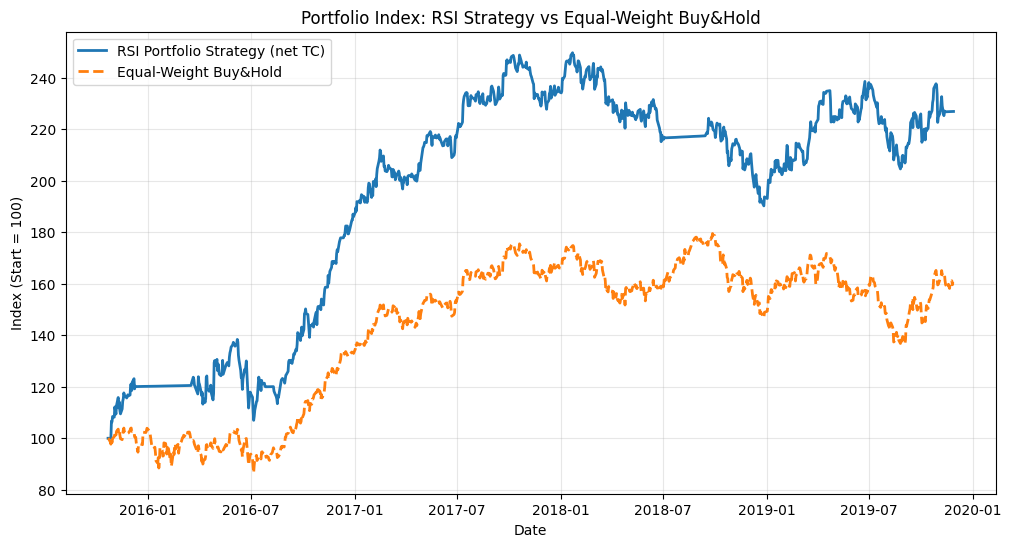

In [6]:
# Returns (log-return framework)
warmup_days = 200
tc = 0.0015  # 0.15% transaction cost per one-way turnover

if len(prices) <= warmup_days:
    raise ValueError('Not enough rows after applying warmup cutoff.')

prices_eval = prices.iloc[warmup_days:].copy()
weights_eval = weights.reindex(prices_eval.index).fillna(0.0)
cash_weight_eval = cash_weight.reindex(prices_eval.index).fillna(1.0)

stock_log_returns = np.log(prices_eval / prices_eval.shift(1)).fillna(0.0)

rf_df = pd.read_csv(rf_path, parse_dates=['Date'], index_col='Date')[::-1]
rf_simple_daily = (rf_df['Price'].astype(float) / 100.0) / 252.0
rf_log_daily = np.log1p(rf_simple_daily).reindex(prices_eval.index).ffill().fillna(0.0)

# Strategy gross return from stock/rf mix
strategy_simple_mix_gross = (weights_eval * np.expm1(stock_log_returns)).sum(axis=1) + cash_weight_eval * np.expm1(rf_log_daily)

# One-way portfolio turnover including cash sleeve
alloc_eval = pd.concat([weights_eval, cash_weight_eval.rename('CASH')], axis=1)
turnover = alloc_eval.diff().abs().sum(axis=1).fillna(0.0) / 2.0
tc_cost = tc * turnover

# Net strategy return after transaction cost
strategy_simple_mix = (strategy_simple_mix_gross - tc_cost).clip(lower=-0.999999)
strategy_log_returns = np.log1p(strategy_simple_mix)

# Benchmark: always equal-weight buy-and-hold across all stocks (log framework)
n_stocks = len(prices_eval.columns)
benchmark_simple_mix = np.expm1(stock_log_returns).sum(axis=1) / n_stocks
benchmark_log_returns = np.log1p(benchmark_simple_mix.clip(lower=-0.999999))

# Keep simple-return versions for APIs expecting simple returns
strategy_simple_returns = np.expm1(strategy_log_returns)
benchmark_simple_returns = np.expm1(benchmark_log_returns)

# Growth indices from log returns
strategy_index = np.exp(strategy_log_returns.cumsum()) * 100.0
benchmark_index = np.exp(benchmark_log_returns.cumsum()) * 100.0

# Quick diagnostics
total_strategy_return = strategy_index.iloc[-1] / 100.0 - 1.0
total_benchmark_return = benchmark_index.iloc[-1] / 100.0 - 1.0

print(f'Strategy total return (net of TC): {total_strategy_return:.2%}')
print(f'Buy&Hold equal-weight total return: {total_benchmark_return:.2%}')
print(f'Evaluation starts after warmup days: {warmup_days}')
print(f'Days with at least one active position (eval window): {(weights_eval.sum(axis=1) > 0).mean():.2%}')
print(f'Average one-way daily turnover: {turnover.mean():.4%}')
print(f'Average daily TC drag: {tc_cost.mean():.4%}')

plt.figure(figsize=(12, 6))
plt.plot(strategy_index.index, strategy_index, label='RSI Portfolio Strategy (net TC)', linewidth=2)
plt.plot(benchmark_index.index, benchmark_index, label='Equal-Weight Buy&Hold', linewidth=2, linestyle='--')
plt.title('Portfolio Index: RSI Strategy vs Equal-Weight Buy&Hold')
plt.xlabel('Date')
plt.ylabel('Index (Start = 100)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

===== RSI Portfolio Strategy vs Simple Equal-Weight Buy&Hold =====
                            OLS Regression Results                            
Dep. Variable:           excess_strat   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     375.7
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.72e-71
Time:                        14:45:26   Log-Likelihood:                 3086.3
No. Observations:                1021   AIC:                            -6169.
Df Residuals:                    1019   BIC:                            -6159.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

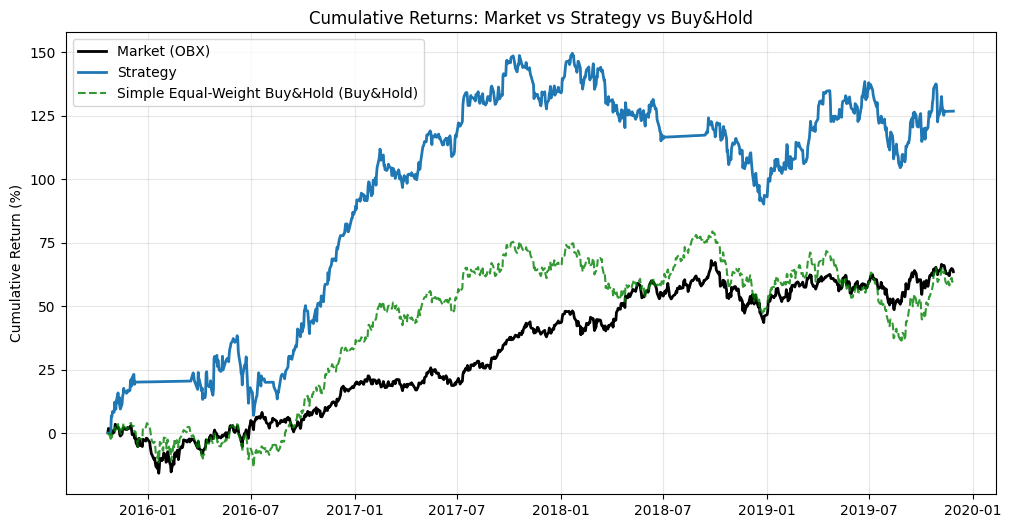

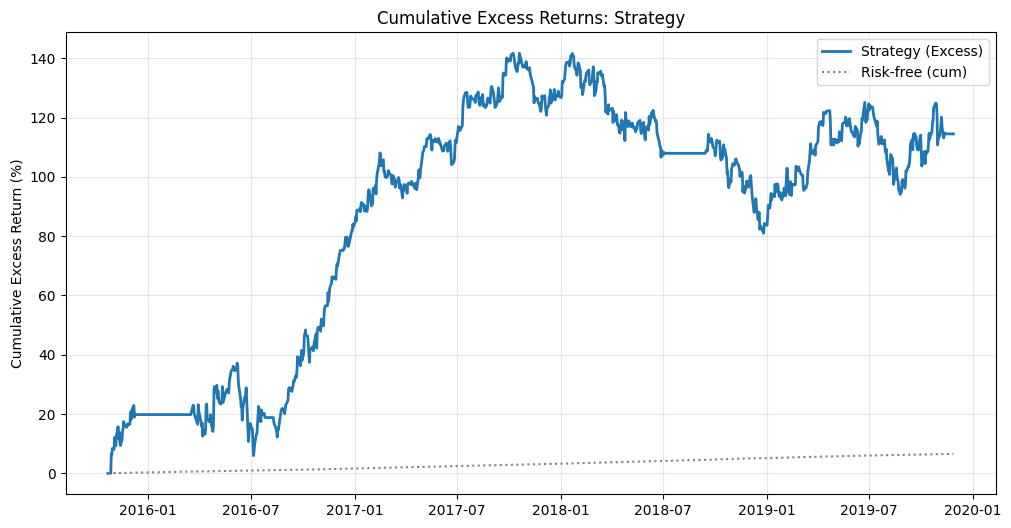

In [7]:
# Run test_strategy once with one benchmark underlying (simple equal-weight buy&hold)
eq_bh_price = np.exp(benchmark_log_returns.cumsum()) * 100.0

print('===== RSI Portfolio Strategy vs Simple Equal-Weight Buy&Hold =====')
res_strategy = test_strategy(
    strategy_returns=np.expm1(strategy_log_returns),
    underlying_prices=[eq_bh_price],
    underlying_names=['Simple Equal-Weight Buy&Hold'],
    dates=prices_eval.index,
    data_dir=str(proj_root / 'data' / 'processed'),
    plot_index=True,
)

In [ ]:
# Consistency audit: look-ahead bias and gearing checks
audit = {}

# 1) No leverage / gearing in portfolio construction
weight_sum = (weights.sum(axis=1) + cash_weight).fillna(0.0)
audit['max_abs_weight_sum_error'] = float((weight_sum - 1.0).abs().max())
audit['max_stock_weight'] = float(weights.max().max())
audit['min_stock_weight'] = float(weights.min().min())

# 2) Position transitions use previous-day signals (implementation check)
# positions[t] should reflect signal_df[t-1], not signal_df[t]
buy_from_prev = ((signal_df.shift(1) == 1) & (positions == 1)).sum().sum()
sell_from_prev = ((signal_df.shift(1) == -1) & (positions == 0)).sum().sum()
audit['buy_matches_prev_signal_count'] = int(buy_from_prev)
audit['sell_matches_prev_signal_count'] = int(sell_from_prev)

# 3) Ensure no NaN leakage after warmup slice in strategy series
audit['strategy_nan_count'] = int(strategy_log_returns.isna().sum())
audit['benchmark_nan_count'] = int(benchmark_log_returns.isna().sum())

# 4) Return bound sanity: simple returns must be > -100%
audit['strategy_min_simple_return'] = float(np.expm1(strategy_log_returns).min())
audit['benchmark_min_simple_return'] = float(np.expm1(benchmark_log_returns).min())

print('=== Audit results ===')
for k, v in audit.items():
    print(f'{k}: {v}')

# Hard assertions for 100% consistency on leverage/index alignment rules
assert audit['max_abs_weight_sum_error'] < 1e-10, 'Weight + cash does not sum to 1 (gearing/cash inconsistency).'
assert audit['max_stock_weight'] <= 1.0 + 1e-12, 'A stock weight exceeds 100% (gearing).'
assert audit['min_stock_weight'] >= -1e-12, 'Negative stock weight detected (shorting/gearing).'
assert audit['strategy_nan_count'] == 0, 'NaN values in strategy returns after warmup.'
assert audit['benchmark_nan_count'] == 0, 'NaN values in benchmark returns after warmup.'
assert audit['strategy_min_simple_return'] > -1.0, 'Invalid strategy simple return <= -100%.'
assert audit['benchmark_min_simple_return'] > -1.0, 'Invalid benchmark simple return <= -100%.'

print('All hard checks passed.')